# Tech Challenge - Classificação de Câncer de Mama

## Contexto
Este notebook apresenta uma proposta de aplicação de Machine Learning para apoiar a triagem de risco em saúde da mulher. O tema escolhido foi o câncer de mama, utilizando o dataset `breast-cancer.csv` para treinar um modelo de Machine Learning a fim de categorizar casos de pacientes como Benigno ou Maligno.

## Objetivo
O objetivo é comparar técnicas de classificação capazes de prever o diagnóstico de câncer de mama (`M` = maligno, `B` = benigno), com atenção especial às métricas mais adequadas ao contexto médico. Como se trata de um problema de triagem, reduzir falsos negativos é especialmente importante, já que classificar um caso maligno como benigno pode atrasar a investigação clínica.

## Estratégia adotada
1. Carregar e inspecionar o dataset.
2. Realizar análise exploratória com estatísticas e visualizações.
3. Executar o pré-processamento dos dados.
4. Treinar e comparar diferentes modelos de classificação.
5. Avaliar o desempenho com validação cruzada e conjunto de teste.
6. Interpretar os modelos treinados com técnicas de explicabilidade compatíveis.

## Bibliotecas utilizadas
Antes de iniciar a análise, são importadas as bibliotecas necessárias para manipulação dos dados, visualização gráfica, treinamento dos modelos e avaliação dos resultados.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_validate, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

sns.set_theme(style='whitegrid', palette='Blues')  # Define um padrao visual consistente para os graficos.
plt.rcParams['figure.figsize'] = (10, 6)  # Ajusta o tamanho padrao das figuras.
pd.set_option('display.max_columns', 100)  # Permite visualizar mais colunas nas tabelas exibidas.
pd.set_option('display.float_format', lambda x: f'{x:.4f}')  # Padroniza a exibicao numerica com quatro casas decimais.


c:\Users\Felipe.Sampaio\Desktop\temp\teste\tech_challenge_1\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Carregamento dos dados
O primeiro passo consiste em carregar o dataset e observar sua estrutura geral. Essa etapa é importante para confirmar o volume de registros, as colunas disponíveis e a natureza do problema que será tratado.

### Leitura inicial
- O dataset possui 569 registros.
- A variável alvo é `diagnosis`, com duas classes: `M` (maligno) e `B` (benigno).
- A coluna `id` funciona apenas como identificador do exame e não representa uma característica clínica útil para o treinamento.
- As demais variáveis são numéricas e descrevem medidas extraídas dos exames.

In [2]:
df = pd.read_csv('dataset/breast-cancer.csv')

print(f'Dimensoes do dataset: {df.shape[0]} linhas e {df.shape[1]} colunas')
display(df.head())

Dimensoes do dataset: 569 linhas e 32 colunas


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.9900,10.3800,122.8000,1001.0000,0.1184,0.2776,0.3001,0.1471,0.2419,0.0787,1.0950,0.9053,8.5890,153.4000,0.0064,0.0490,0.0537,0.0159,0.0300,0.0062,25.3800,17.3300,184.6000,2019.0000,0.1622,0.6656,0.7119,0.2654,0.4601,0.1189
1,842517,M,20.5700,17.7700,132.9000,1326.0000,0.0847,0.0786,0.0869,0.0702,0.1812,0.0567,0.5435,0.7339,3.3980,74.0800,0.0052,0.0131,0.0186,0.0134,0.0139,0.0035,24.9900,23.4100,158.8000,1956.0000,0.1238,0.1866,0.2416,0.1860,0.2750,0.0890
2,84300903,M,19.6900,21.2500,130.0000,1203.0000,0.1096,0.1599,0.1974,0.1279,0.2069,0.0600,0.7456,0.7869,4.5850,94.0300,0.0062,0.0401,0.0383,0.0206,0.0225,0.0046,23.5700,25.5300,152.5000,1709.0000,0.1444,0.4245,0.4504,0.2430,0.3613,0.0876
3,84348301,M,11.4200,20.3800,77.5800,386.1000,0.1425,0.2839,0.2414,0.1052,0.2597,0.0974,0.4956,1.1560,3.4450,27.2300,0.0091,0.0746,0.0566,0.0187,0.0596,0.0092,14.9100,26.5000,98.8700,567.7000,0.2098,0.8663,0.6869,0.2575,0.6638,0.1730
4,84358402,M,20.2900,14.3400,135.1000,1297.0000,0.1003,0.1328,0.1980,0.1043,0.1809,0.0588,0.7572,0.7813,5.4380,94.4400,0.0115,0.0246,0.0569,0.0188,0.0176,0.0051,22.5400,16.6700,152.2000,1575.0000,0.1374,0.2050,0.4000,0.1625,0.2364,0.0768


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

## 2. Análise exploratória dos dados
Nesta etapa, são examinadas estatísticas descritivas, distribuições e relações entre variáveis. O objetivo é compreender melhor o comportamento dos dados antes do processo de modelagem.

### Estatísticas descritivas e distribuição das classes
A seguir são apresentados um resumo estatístico das variáveis numéricas e a distribuição da variável alvo. Essas duas leituras ajudam a entender a escala dos atributos e o equilíbrio entre as classes.

### Estatísticas descritivas

In [4]:
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
id,569.0000,30371831.4323,125020585.6122,8670.0000,869218.0000,906024.0000,8813129.0000,911320502.0000
radius_mean,569.0000,14.1273,3.5240,6.9810,11.7000,13.3700,15.7800,28.1100
texture_mean,569.0000,19.2896,4.3010,9.7100,16.1700,18.8400,21.8000,39.2800
perimeter_mean,569.0000,91.9690,24.2990,43.7900,75.1700,86.2400,104.1000,188.5000
area_mean,569.0000,654.8891,351.9141,143.5000,420.3000,551.1000,782.7000,2501.0000
smoothness_mean,569.0000,0.0964,0.0141,0.0526,0.0864,0.0959,0.1053,0.1634
compactness_mean,569.0000,0.1043,0.0528,0.0194,0.0649,0.0926,0.1304,0.3454
concavity_mean,569.0000,0.0888,0.0797,0.0000,0.0296,0.0615,0.1307,0.4268
concave points_mean,569.0000,0.0489,0.0388,0.0000,0.0203,0.0335,0.0740,0.2012
symmetry_mean,569.0000,0.1812,0.0274,0.1060,0.1619,0.1792,0.1957,0.3040


O resumo estatístico mostra que as variáveis do dataset estão em escalas bastante diferentes, com valores pequenos em atributos como `smoothness_mean` e valores muito maiores em atributos como `area_mean` e `area_worst`. Além disso, a diferença entre mínimo, média, mediana e máximo sugere que algumas medidas apresentam alta dispersão, o que reforça a necessidade de padronização para modelos sensíveis à escala, como Regressão Logística e KNN.

### Distribuição das classes

,diagnosis,count,percentual
0,B,357,62.7417
1,M,212,37.2583


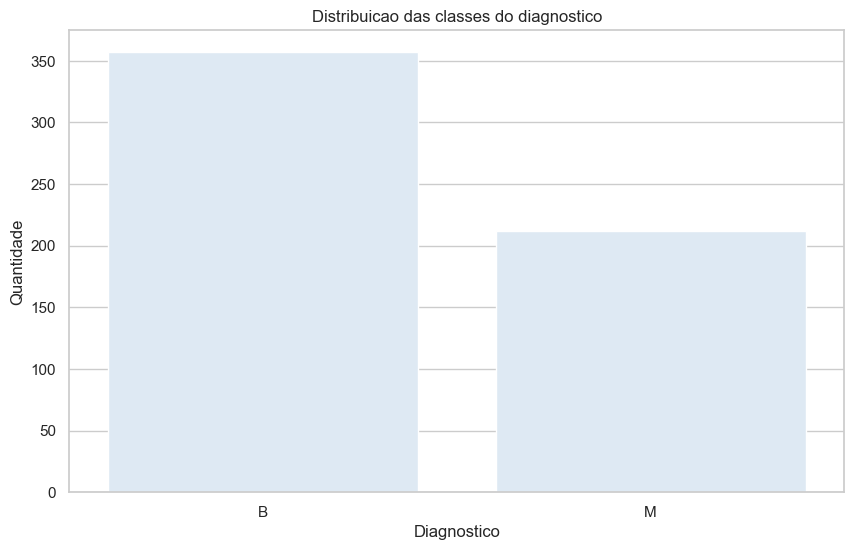

In [5]:
class_dist = df['diagnosis'].value_counts().rename_axis('diagnosis').reset_index(name='count')  # Quantidade por classe.
class_dist['percentual'] = 100 * class_dist['count'] / class_dist['count'].sum()  # Converte a contagem em percentual para facilitar a leitura.
display(class_dist)  # Exibe a tabela resumida da distribuicao

fig, ax = plt.subplots()  # Cria a figura e o eixo que receberao o grafico.
sns.countplot(data=df, x='diagnosis', order=['B', 'M'], ax=ax)  # Plota a quantidade de registros por classe.
ax.set_title('Distribuicao das classes do diagnostico')
ax.set_xlabel('Diagnostico')
ax.set_ylabel('Quantidade')
plt.show()

Há mais casos benignos do que malignos. Ainda assim, o desbalanceamento não é severo. Isso reforça a importância de utilizar separação estratificada entre treino e teste e de acompanhar, além da acurácia, métricas como `recall` e `f1-score`.

### Análise de correlação
A correlação é observada em duas perspectivas: a relação geral entre as variáveis numéricas e a associação específica de cada atributo com o diagnóstico.

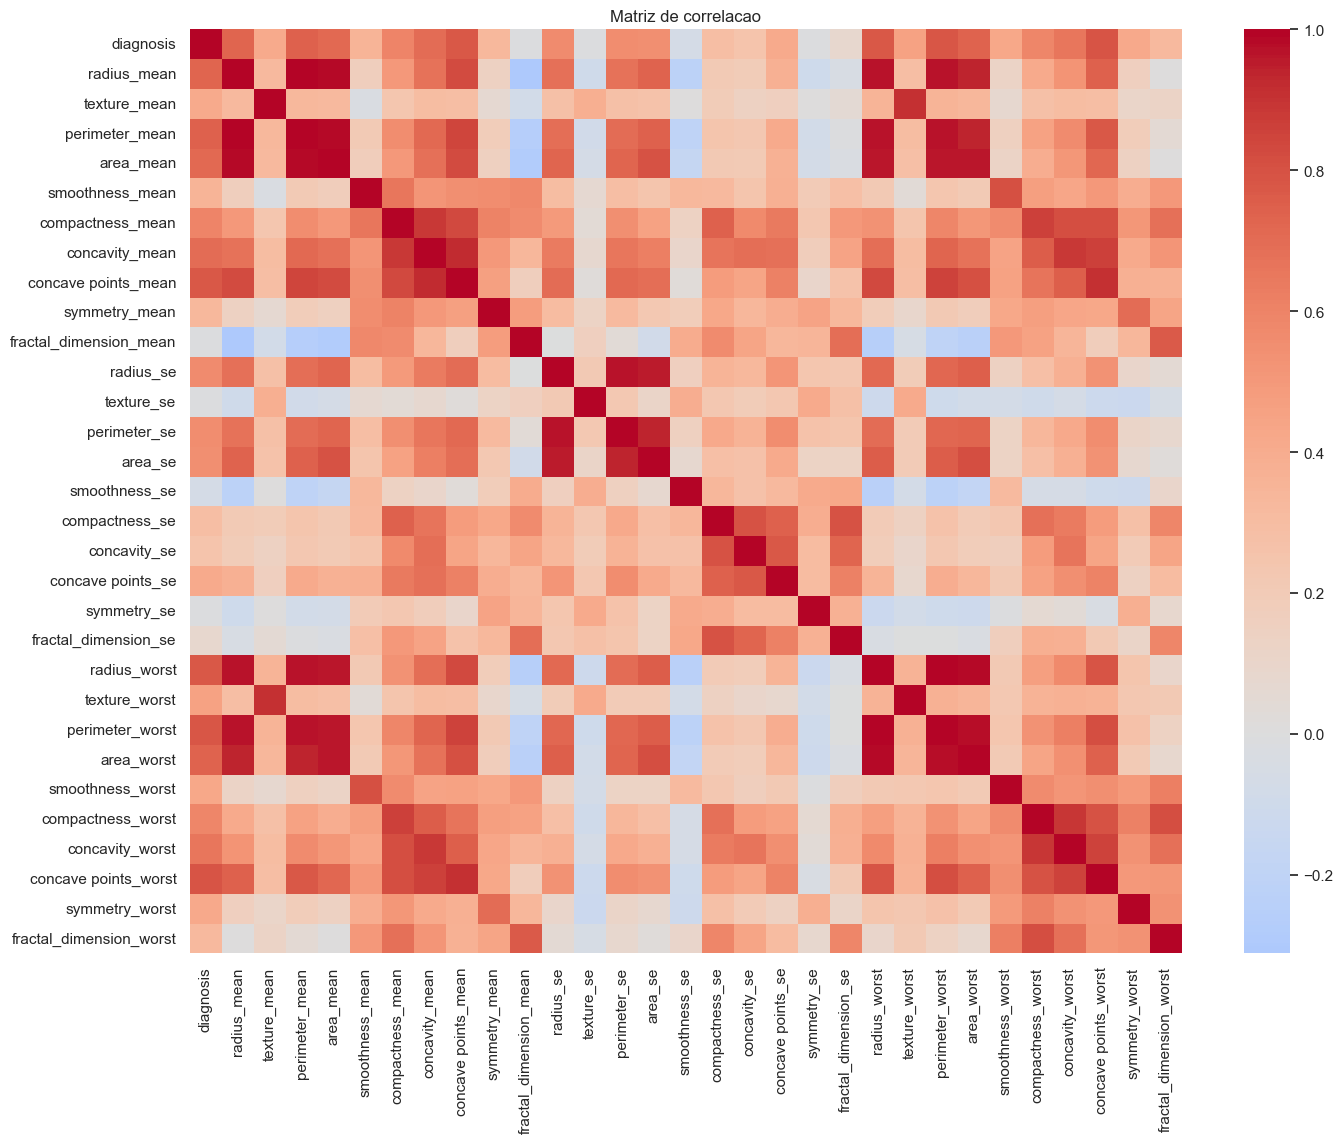

In [6]:
corr = df.drop(columns=['id']).copy()  # Remove o identificador para analisar apenas variaveis relevantes ao problema.

correlation_encoder = LabelEncoder()  # Converte o diagnostico para formato numerico, necessario para calcular a correlacao com a variavel target.
corr['diagnosis'] = correlation_encoder.fit_transform(corr['diagnosis'])

corr_matrix = corr.corr(numeric_only=True)  # Calcula a matriz de correlacao entre as variaveis numericas e o diagnostico.

plt.figure(figsize=(16, 12))  # Definições do estilo da matriz
sns.heatmap(corr_matrix, cmap='coolwarm', center=0)  # Exibe as correlacoes positivas e negativas em uma escala de cores.
plt.title('Matriz de correlacao')
plt.show()


In [ ]:
target_corr = corr_matrix['diagnosis'].drop('diagnosis').sort_values(key=np.abs, ascending=False)  # Ordena as variaveis pela forca de correlacao com o diagnostico.
display(target_corr.head(10).to_frame('correlacao_com_diagnosis'))  # Exibe apenas as dez variaveis mais associadas ao alvo para facilitar a interpretacao.


A matriz de correlação permite identificar tanto variáveis fortemente relacionadas entre si quanto aquelas mais associadas ao diagnóstico. Essa leitura é útil para a interpretação dos resultados, para a identificação de possíveis redundâncias e para justificar o uso de modelos mais sensíveis à escala e à proximidade, como o KNN.

### Visualização de variáveis selecionadas
Para complementar a análise exploratória, os boxplots utilizam variáveis com forte correlação com o diagnóstico, mas com diversidade de informação. A escolha evita concentrar a visualização em atributos muito semelhantes entre si, como `radius`, `perimeter` e `area`, que representam dimensões próximas da lesão. Assim, foram selecionadas `concave points_worst`, `radius_worst`, `concavity_mean` e `compactness_mean`, pois elas apresentam alta associação com o alvo e, ao mesmo tempo, cobrem aspectos diferentes da lesão.

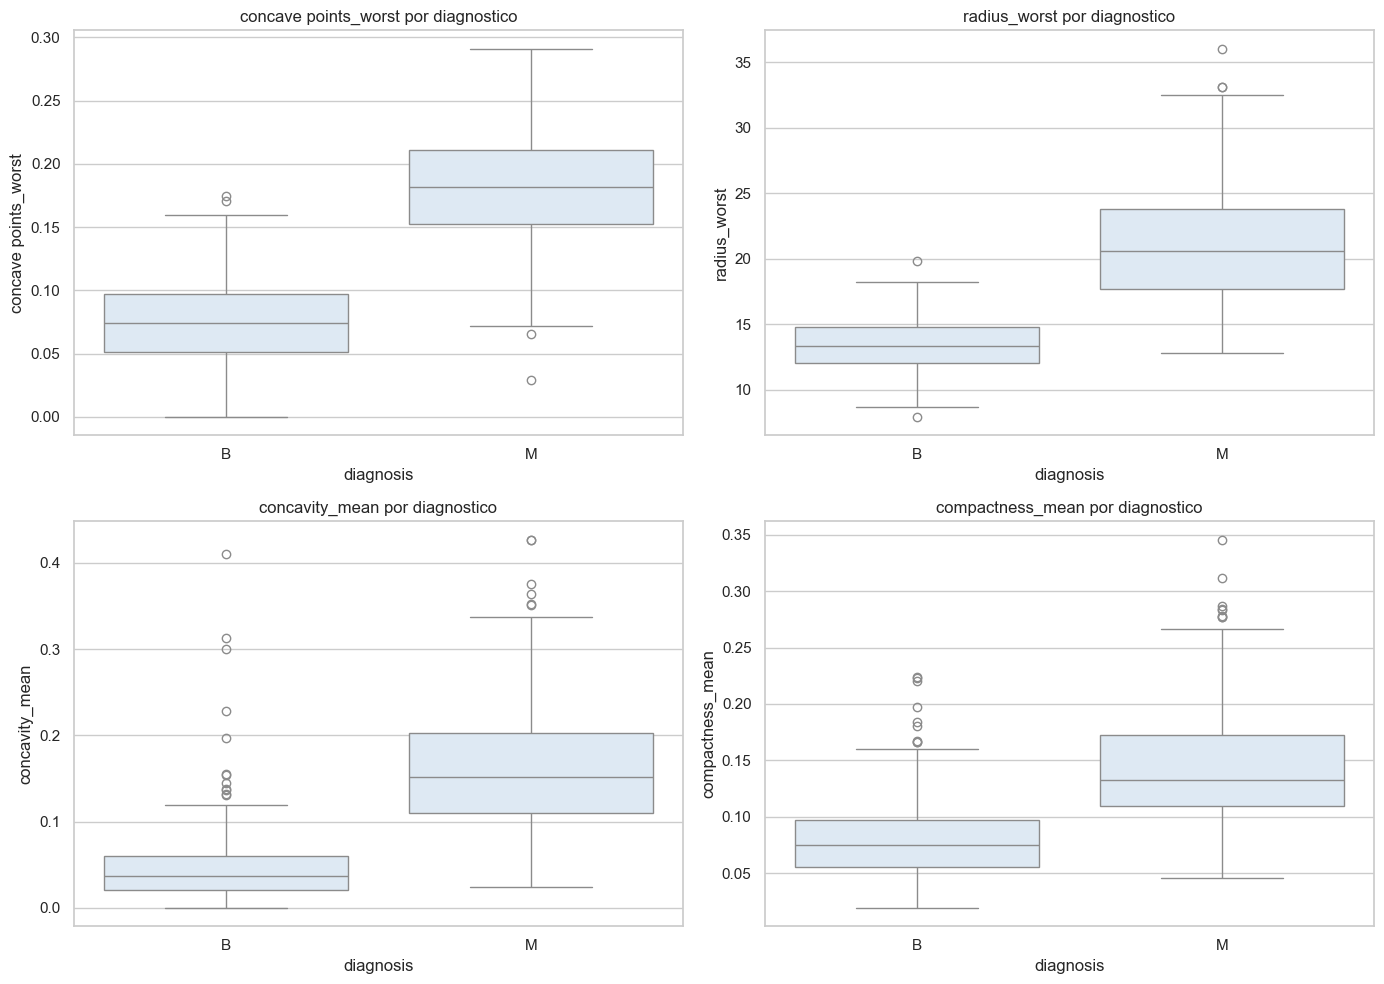

In [7]:
selected_features = ['concave points_worst', 'radius_worst', 'concavity_mean', 'compactness_mean']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))  # Cria uma grade 2x2 para comparar as quatro variaveis selecionadas.
for ax, feature in zip(axes.flatten(), selected_features):  # Associa cada eixo a uma variavel da lista.
    sns.boxplot(data=df, x='diagnosis', y=feature, order=['B', 'M'], ax=ax)  # Exibe a distribuicao da variavel por classe.
    ax.set_title(f'{feature} por diagnostico')  # Identifica qual atributo esta sendo mostrado em cada grafico.
plt.tight_layout()  # Ajusta o espacamento entre os subplots.
plt.show()


Os boxplots ajudam a verificar se algumas medidas apresentam separação visual entre casos benignos e malignos. Ao selecionar variáveis com alta correlação e menor sobreposição de significado, a visualização fica mais informativa e evita repetir, em excesso, o mesmo tipo de evidência estatística. Nos gráficos, observa-se que os casos malignos tendem a concentrar valores mais altos em variáveis como `concave points_worst`, `radius_worst`, `concavity_mean` e `compactness_mean`, o que reforça a utilidade dessas medidas para diferenciar os dois grupos. Apesar de existir alguma sobreposição entre as distribuições, a separação visual é suficiente para indicar que essas variáveis carregam sinal relevante para a classificação.

## 3. Pré-processamento dos dados

### Decisões de pré-processamento
1. **Valores ausentes**: o dataset não apresenta valores ausentes, portanto não foi necessário imputar dados na base original. Ainda assim, os pipelines incluem `SimpleImputer` como boa prática de reprodutibilidade.
2. **Inconsistências**: não foram observadas inconsistências de tipo ou formato nas variáveis numéricas.
3. **Remoção da coluna `id`**: essa coluna atua apenas como identificador e não traz informação clínica relevante para a generalização do modelo.
4. **Codificação da variável alvo**: a classe `diagnosis` foi convertida para formato numérico (`B = 0`, `M = 1`) para utilização nos algoritmos.
5. **Escalonamento**: foi aplicado `StandardScaler` nos modelos sensíveis à escala, como Regressão Logística e KNN.
6. **Separação treino/teste**: foi utilizada divisão estratificada para preservar a proporção entre benigno e maligno nos subconjuntos.

### Verificação de qualidade dos dados
Antes da preparação para a modelagem, são verificados valores ausentes e possíveis duplicidades para confirmar que a base está consistente.

In [8]:
missing_values = df.isna().sum().sort_values(ascending=False) # Busca a quantidade de valores ausentes por feature.
duplicated_rows = df.duplicated().sum() # Busca a quantidade de dados duplicados.

print('Valores ausentes por coluna:')
display(missing_values.to_frame('missing'))
print(f'Linhas duplicadas: {duplicated_rows}')

Valores ausentes por coluna:


,missing
id,0
diagnosis,0
symmetry_worst,0
concave points_worst,0
concavity_worst,0
compactness_worst,0
smoothness_worst,0
area_worst,0
perimeter_worst,0
texture_worst,0


Linhas duplicadas: 0


### Transformações aplicadas
Nesta etapa são feitas a remoção do identificador, a codificação da variável alvo e a separação entre variáveis explicativas e variável resposta.

In [9]:
df_model = df.copy()
df_model = df_model.drop(columns=['id'])  # Remove o identificador, que nao acrescenta informacao util para a classificacao.

label_encoder = LabelEncoder()
df_model['diagnosis_encoded'] = label_encoder.fit_transform(df_model['diagnosis'])  # Codifica a variavel alvo em formato numerico para uso nos modelos.

X = df_model.drop(columns=['diagnosis', 'diagnosis_encoded'])  # Separa apenas as variaveis preditoras.
y = df_model['diagnosis_encoded']  # Separa a variavel target que sera prevista pelos modelos.

print('Visualizacao dos dados apos remocao do ID e codificacao do alvo:')
display(X.head())
display(y.head())


Visualizacao dos dados apos remocao do ID e codificacao do alvo:


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,17.9900,10.3800,122.8000,1001.0000,0.1184,0.2776,0.3001,0.1471,0.2419,0.0787,1.0950,0.9053,8.5890,153.4000,0.0064,0.0490,0.0537,0.0159,0.0300,0.0062,25.3800,17.3300,184.6000,2019.0000,0.1622,0.6656,0.7119,0.2654,0.4601,0.1189
1,20.5700,17.7700,132.9000,1326.0000,0.0847,0.0786,0.0869,0.0702,0.1812,0.0567,0.5435,0.7339,3.3980,74.0800,0.0052,0.0131,0.0186,0.0134,0.0139,0.0035,24.9900,23.4100,158.8000,1956.0000,0.1238,0.1866,0.2416,0.1860,0.2750,0.0890
2,19.6900,21.2500,130.0000,1203.0000,0.1096,0.1599,0.1974,0.1279,0.2069,0.0600,0.7456,0.7869,4.5850,94.0300,0.0062,0.0401,0.0383,0.0206,0.0225,0.0046,23.5700,25.5300,152.5000,1709.0000,0.1444,0.4245,0.4504,0.2430,0.3613,0.0876
3,11.4200,20.3800,77.5800,386.1000,0.1425,0.2839,0.2414,0.1052,0.2597,0.0974,0.4956,1.1560,3.4450,27.2300,0.0091,0.0746,0.0566,0.0187,0.0596,0.0092,14.9100,26.5000,98.8700,567.7000,0.2098,0.8663,0.6869,0.2575,0.6638,0.1730
4,20.2900,14.3400,135.1000,1297.0000,0.1003,0.1328,0.1980,0.1043,0.1809,0.0588,0.7572,0.7813,5.4380,94.4400,0.0115,0.0246,0.0569,0.0188,0.0176,0.0051,22.5400,16.6700,152.2000,1575.0000,0.1374,0.2050,0.4000,0.1625,0.2364,0.0768


0    1
1    1
2    1
3    1
4    1
Name: diagnosis_encoded, dtype: int32

### Separação entre treino e teste
A divisão estratificada preserva a proporção entre casos benignos e malignos, o que torna a avaliação mais representativa do problema.

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,  # Preserva a proporcao entre benigno e maligno em treino e teste.
    random_state=42
)

print('Dimensoes dos conjuntos:')
print(f'Treino: {X_train.shape}')
print(f'Teste: {X_test.shape}')


Dimensoes dos conjuntos:
Treino: (455, 30)
Teste: (114, 30)


### Escalonamento das variáveis numéricas
Como alguns algoritmos são sensíveis à escala, os dados numéricos do conjunto de treino são padronizados.

In [11]:
numeric_features = X.columns.tolist()

scaled_preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),  # Mantido no pipeline para robustez, mesmo sem ausentes na base atual.
            ('scaler', StandardScaler())  # Necessario para modelos sensiveis a escala, como KNN e Regressao Logistica.
        ]), numeric_features)
    ],
    remainder='drop'  # Mantem apenas as colunas tratadas no pipeline de pre-processamento.
)

preview_scaler = Pipeline([
    ('preprocessor', scaled_preprocessor)  # Cria um Pipeline de pre-processamento para aplicar a transformacao de forma organizada.
])

X_train_scaled_preview = preview_scaler.fit_transform(X_train)  # Ajusta o escalonamento com base no treino e transforma os dados.
X_train_scaled_preview = pd.DataFrame(X_train_scaled_preview, columns=numeric_features, index=X_train.index)  # Reconstroi o resultado em DataFrame para facilitar a leitura.

print('Amostra dos dados numericos apos escalonamento (treino):')
display(X_train_scaled_preview.head())


Amostra dos dados numericos apos escalonamento (treino):


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,perimeter_se,area_se,smoothness_se,compactness_se,concavity_se,concave points_se,symmetry_se,fractal_dimension_se,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
10,0.5186,0.8918,0.4246,0.3839,-0.9747,-0.6898,-0.6886,-0.3982,-1.0392,-0.8251,-0.1093,-0.0560,-0.2101,-0.0159,-1.0052,-0.9119,-0.6628,-0.6526,-0.7019,-0.2754,0.5798,1.3132,0.4669,0.4460,-0.5962,-0.6347,-0.6102,-0.2357,0.0546,0.0218
170,-0.5164,-1.6397,-0.5413,-0.5430,0.4762,-0.6318,-0.6043,-0.3031,0.5215,-0.4545,-0.6044,-1.0010,-0.5854,-0.4935,0.4032,-0.7682,-0.4792,0.1145,-0.1430,-0.5774,-0.5825,-1.6903,-0.6119,-0.5870,0.2736,-0.8148,-0.7127,-0.3232,-0.1376,-0.9044
407,-0.3681,0.4555,-0.3882,-0.4030,-1.4330,-0.3839,-0.3422,-0.7655,-0.8509,-0.2262,0.3040,1.0515,-0.1695,-0.0008,-0.3101,1.1063,0.6226,0.2737,0.7545,1.5081,-0.3986,0.1820,-0.4754,-0.4208,-1.6228,-0.3914,-0.4313,-0.8908,-0.6759,-0.1440
430,0.2053,0.7262,0.4003,0.0706,0.2433,2.2036,2.2561,1.2132,0.8185,0.8998,-0.5457,-0.6217,0.2614,-0.3536,0.0245,2.0907,1.4906,1.6951,-0.6549,0.7675,-0.0003,0.2742,0.5138,-0.0995,0.4185,2.8660,2.9586,1.9771,-0.0756,1.7288
27,1.2430,0.1942,1.2104,1.2067,-0.1114,0.0513,0.7330,0.7138,-0.4272,-0.8222,1.5239,1.1439,1.2827,1.0813,1.3518,0.1077,0.5929,1.1810,0.3015,0.1715,1.0128,0.2231,0.9385,0.8809,0.0732,-0.2770,0.3278,0.5019,-0.9093,-0.5462


## 4. Modelagem
Foram escolhidos três algoritmos de classificação com comportamentos distintos, de modo a permitir uma comparação mais consistente:

- **Regressão Logística**: modelo linear, de fácil interpretação e bastante útil como referência inicial em problemas de classificação binária.
- **KNN**: modelo baseado em proximidade, sensível à escala das variáveis e interessante para comparação com uma abordagem não paramétrica.
- **Random Forest**: conjunto de árvores de decisão capaz de capturar relações não lineares e fornecer medidas de importância das variáveis.

### Configuração dos modelos
Cada algoritmo é definido com um pipeline apropriado, o que garante consistência entre pré-processamento e treinamento durante as etapas de validação e teste.

### Análise dos hiperparâmetros
Definir os hiperparâmetros é importante para evitar escolhas arbitrárias e aumentar a confiança no comportamento dos modelos. Esta etapa testa combinações plausíveis e seleciona configurações coerentes com o problema e com a métrica prioritária da análise.

As decisões consideradas nesta etapa foram:

- **Regressão Logística**: testar diferentes valores de `C`, que controla o nível de regularização do modelo.
- **KNN**: primeiro analisar a curva de erro médio para levantar candidatos de `n_neighbors` e, depois, testar esses valores junto com `weights` e `metric`, já que esses parâmetros alteram diretamente a noção de proximidade.
- **Random Forest**: testar combinações de `n_estimators`, `max_depth` e `min_samples_leaf`, pois esses parâmetros influenciam a complexidade e a estabilidade da floresta.

Como o objetivo é apoiar a triagem, a busca também prioriza o `recall` na base de treinamento, mantendo coerência com o critério adotado para comparar os modelos.


### Análise do `n_neighbors` no KNN
Antes da busca final de hiperparâmetros do KNN, é útil observar como o erro médio varia conforme o número de vizinhos. Essa leitura ajuda a evitar uma escolha arbitrária de `n_neighbors` e permite selecionar candidatos mais promissores para a etapa seguinte.

No gráfico, pontos em que o erro fica mais baixo e regiões em que a curva muda de inclinação funcionam como bons candidatos para teste. Assim, o `GridSearchCV` do KNN passa a trabalhar com valores previamente filtrados por essa análise.


,n_neighbors,accuracy_media,erro_medio
0,1,0.9560,0.0440
1,2,0.9604,0.0396
2,3,0.9736,0.0264
3,4,0.9626,0.0374
4,5,0.9648,0.0352
5,6,0.9604,0.0396
6,7,0.9692,0.0308
7,8,0.9626,0.0374
8,9,0.9648,0.0352
9,10,0.9604,0.0396


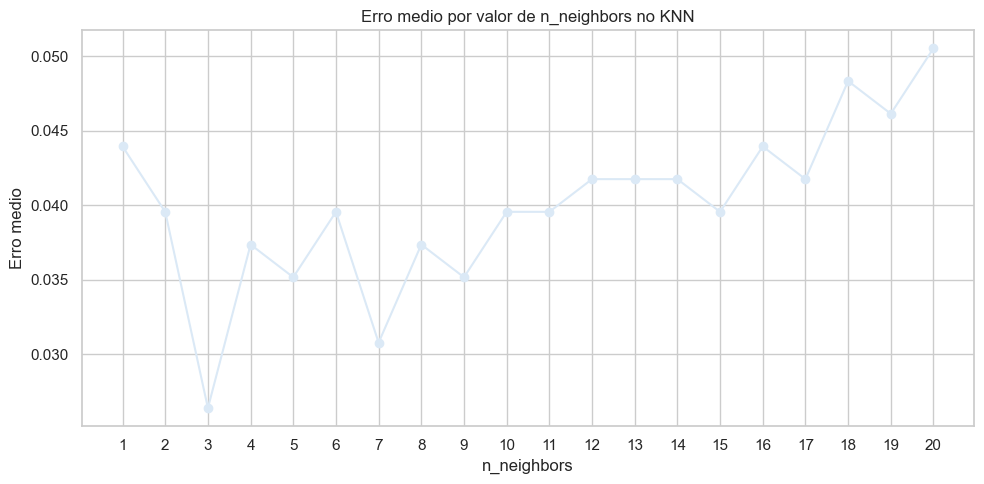

Candidatos selecionados para o GridSearchCV do KNN: [3, 5, 7, 9]


In [12]:
tuning_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

knn_k_results = []

for k in range(1, 21):
    knn_candidate_pipeline = Pipeline([
        ('preprocessor', scaled_preprocessor),
        ('model', KNeighborsClassifier(n_neighbors=k))
    ])  # Monta um pipeline temporario para medir o efeito de cada valor de k no desempenho medio.

    knn_scores = cross_validate(
        knn_candidate_pipeline,
        X_train,
        y_train,
        cv=tuning_cv,
        scoring='accuracy',
        n_jobs=1
    )  # Usa validacao cruzada para estimar o erro medio sem depender de uma unica divisao.

    knn_k_results.append({
        'n_neighbors': k,
        'accuracy_media': knn_scores['test_score'].mean(),
        'erro_medio': 1 - knn_scores['test_score'].mean()
    })

knn_k_results_df = pd.DataFrame(knn_k_results)
display(knn_k_results_df.head(10))

plt.figure(figsize=(10, 5))
plt.plot(knn_k_results_df['n_neighbors'], knn_k_results_df['erro_medio'], marker='o')
plt.title('Erro medio por valor de n_neighbors no KNN')
plt.xlabel('n_neighbors')
plt.ylabel('Erro medio')
plt.xticks(knn_k_results_df['n_neighbors'])
plt.tight_layout()
plt.show()

knn_candidate_neighbors = [3, 5, 7, 9]  # Escolhe candidatos em regioes de menor erro e em pontos proximos de mudanca de inclinacao.
print(f'Candidatos selecionados para o GridSearchCV do KNN: {knn_candidate_neighbors}')


In [13]:
tuning_setups = {
    'Regressao Logistica': {
        'pipeline': Pipeline([
            ('preprocessor', scaled_preprocessor),
            ('model', LogisticRegression(max_iter=2000, random_state=42))
        ]),
        'param_grid': {
            'model__C': [0.1, 1, 10]
        }  # Testa niveis de regularizacao para equilibrar ajuste e generalizacao.
    },
    'KNN': {
        'pipeline': Pipeline([
            ('preprocessor', scaled_preprocessor),
            ('model', KNeighborsClassifier())
        ]),
        'param_grid': {
            'model__n_neighbors': knn_candidate_neighbors,
            'model__weights': ['uniform', 'distance'],
            'model__metric': ['euclidean', 'manhattan']
        }  # Testa no grid apenas os valores de k previamente selecionados pela curva de erro medio.
    },
    'Random Forest': {
        'pipeline': Pipeline([
            ('preprocessor', ColumnTransformer(
                transformers=[
                    ('num', Pipeline([
                        ('imputer', SimpleImputer(strategy='median'))
                    ]), numeric_features)
                ],
                remainder='drop'
            )),
            ('model', RandomForestClassifier(random_state=42))
        ]),
        'param_grid': {
            'model__n_estimators': [100, 300],
            'model__max_depth': [None, 5, 10],
            'model__min_samples_leaf': [1, 2]
        }  # Avalia quantidade de arvores e nivel de profundidade para controlar a complexidade da floresta.
    }
}

tuning_results = []
best_params_by_model = {}

for model_name, config in tuning_setups.items():
    grid = GridSearchCV(
        estimator=config['pipeline'],
        param_grid=config['param_grid'],
        scoring='recall',
        cv=tuning_cv,
        n_jobs=1
    )  # Usa validacao cruzada para comparar combinacoes de hiperparametros no conjunto de treino.

    grid.fit(X_train, y_train)

    best_params_by_model[model_name] = grid.best_params_
    tuning_results.append({
        'modelo': model_name,
        'melhor_recall_cv': grid.best_score_,
        'C_escolhido': grid.best_params_.get('model__C', '-'),
        'n_neighbors_escolhido': grid.best_params_.get('model__n_neighbors', '-'),
        'weights_escolhido': grid.best_params_.get('model__weights', '-'),
        'metric_escolhida': grid.best_params_.get('model__metric', '-'),
        'n_estimators_escolhido': grid.best_params_.get('model__n_estimators', '-'),
        'max_depth_escolhido': grid.best_params_.get('model__max_depth', '-'),
        'min_samples_leaf_escolhido': grid.best_params_.get('model__min_samples_leaf', '-')
    })

tuning_results_df = pd.DataFrame(tuning_results)
display(tuning_results_df)


,modelo,melhor_recall_cv,C_escolhido,n_neighbors_escolhido,weights_escolhido,metric_escolhida,n_estimators_escolhido,max_depth_escolhido,min_samples_leaf_escolhido
0,Regressao Logistica,0.9529,1,-,-,-,-,-,-
1,KNN,0.9471,-,3,uniform,manhattan,-,-,-
2,Random Forest,0.9471,-,-,-,-,100,5,1


A tabela resume, para cada algoritmo, a combinação que obteve melhor `recall` médio na validação cruzada. Com isso, os hiperparâmetros deixam de ser definidos de forma arbitrária e passam a refletir uma escolha orientada por desempenho.

No caso do **KNN**, a escolha foi feita em duas etapas: primeiro a curva de erro médio ajudou a reduzir o conjunto de candidatos para `n_neighbors`; depois, o `GridSearchCV` comparou esses valores junto com `weights` e `metric`. Nesta execução, o melhor resultado ocorreu com `n_neighbors=3`, `weights='uniform'` e `metric='manhattan'`, o que sugere uma vizinhança mais enxuta e sensível à estrutura local dos dados, sem diferenciação adicional de peso entre os vizinhos selecionados.

Na **Regressão Logística**, o valor `C=1` manteve um equilíbrio adequado entre regularização e capacidade de ajuste. No **Random Forest**, a combinação com `100` árvores, `max_depth=5` e `min_samples_leaf=1` indicou uma floresta relativamente controlada em profundidade, buscando reduzir excesso de complexidade sem perder flexibilidade.

Depois dessa análise, os modelos finais passam a ser configurados com os melhores valores encontrados para cada caso.


In [14]:
models = {
    'Regressao Logistica': Pipeline([
        ('preprocessor', scaled_preprocessor),
        ('model', LogisticRegression(
            C=best_params_by_model['Regressao Logistica']['model__C'],
            max_iter=2000,
            random_state=42
        ))  # Usa o valor de C selecionado na busca para manter o nivel de regularizacao mais adequado.
    ]),
    'KNN': Pipeline([
        ('preprocessor', scaled_preprocessor),
        ('model', KNeighborsClassifier(
            n_neighbors=best_params_by_model['KNN']['model__n_neighbors'],
            weights=best_params_by_model['KNN']['model__weights'],
            metric=best_params_by_model['KNN']['model__metric']
        ))  # Aplica a configuracao de vizinhanca e distancia que apresentou melhor recall medio.
    ]),
    'Random Forest': Pipeline([
        ('preprocessor', ColumnTransformer(
            transformers=[
                ('num', Pipeline([
                    ('imputer', SimpleImputer(strategy='median'))
                ]), numeric_features)
            ],
            remainder='drop'
        )),  # Arvores nao dependem de escalonamento, por isso o seu pipeline difere dos demais.
        ('model', RandomForestClassifier(
            n_estimators=best_params_by_model['Random Forest']['model__n_estimators'],
            max_depth=best_params_by_model['Random Forest']['model__max_depth'],
            min_samples_leaf=best_params_by_model['Random Forest']['model__min_samples_leaf'],
            random_state=42
        ))  # Mantem a configuracao da floresta que equilibrou melhor recall e complexidade no treino.
    ])
}

models


{'Regressao Logistica': Pipeline(steps=[('preprocessor',
                  ColumnTransformer(transformers=[('num',
                                                   Pipeline(steps=[('imputer',
                                                                    SimpleImputer(strategy='median')),
                                                                   ('scaler',
                                                                    StandardScaler())]),
                                                   ['radius_mean',
                                                    'texture_mean',
                                                    'perimeter_mean',
                                                    'area_mean',
                                                    'smoothness_mean',
                                                    'compactness_mean',
                                                    'concavity_mean',
                                                    '

## 5. Validação cruzada
Antes da avaliação final no conjunto de teste, cada modelo é analisado por validação cruzada estratificada. Essa etapa reduz a dependência de uma única divisão da base e ajuda a estimar a estabilidade do desempenho.

### Critério de comparação
Como o problema envolve apoio à triagem de um possível câncer, o `recall` da classe maligna recebe atenção especial. Em seguida, o `f1-score` ajuda a equilibrar `precision` e `recall`. A `accuracy` continua sendo uma métrica relevante, mas não deve ser usada isoladamente em um contexto médico.

In [15]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['accuracy', 'precision', 'recall', 'f1']

cv_results = []

for model_name, pipeline in models.items(): # Realiza a análise para cada modelo
    scores = cross_validate(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=1,  # Mantido em 1 para evitar instabilidades de paralelismo neste ambiente Windows.
        return_train_score=False
    )
    cv_results.append({
        'modelo': model_name,
        'accuracy_medio': scores['test_accuracy'].mean(),
        'precision_medio': scores['test_precision'].mean(),
        'recall_medio': scores['test_recall'].mean(),
        'f1_medio': scores['test_f1'].mean(),
        'accuracy_std': scores['test_accuracy'].std(),
        'recall_std': scores['test_recall'].std(),
        'f1_std': scores['test_f1'].std()
    })

cv_results_df = pd.DataFrame(cv_results).sort_values(
    by=['recall_medio', 'f1_medio', 'accuracy_medio'],
    ascending=False
).reset_index(drop=True)  # Ordena os resultados pelos critérios prioritários.

display(cv_results_df)


,modelo,accuracy_medio,precision_medio,recall_medio,f1_medio,accuracy_std,recall_std,f1_std
0,Regressao Logistica,0.9736,0.9771,0.9529,0.9640,0.0149,0.0399,0.0207
1,KNN,0.9758,0.9877,0.9471,0.9667,0.0162,0.0343,0.0223
2,Random Forest,0.9670,0.9645,0.9471,0.9553,0.0209,0.0390,0.0284


Os resultados mostram o desempenho médio de cada modelo ao longo das divisões da validação cruzada. Como o critério adotado prioriza `recall`, a Regressão Logística aparece como a alternativa mais adequada neste cenário, por combinar melhor capacidade de identificar casos malignos com desempenho geral consistente. O Random Forest e o KNN também apresentaram resultados competitivos, mas ficaram ligeiramente abaixo nesse critério de priorização.

## 6. Treinamento final e avaliação no conjunto de teste

Na comparação final, o principal ponto de atenção é a capacidade de identificar corretamente os casos malignos. Quando dois modelos apresentam `accuracy` semelhante, tende a ser mais adequado priorizar aquele com melhor `recall` e `f1-score` para a classe de maior risco.

### Resultados no conjunto de teste
Depois da validação cruzada, os modelos são treinados no conjunto de treino e comparados no conjunto de teste com as métricas definidas anteriormente.

In [16]:
test_results = []
fitted_models = {}

for model_name, pipeline in models.items(): # Realiza o treino e a predição para cada modelo.
    pipeline.fit(X_train, y_train)
    fitted_models[model_name] = pipeline  # Armazena os modelos ajustados para reutilizar na avaliacao e explicabilidade.

    y_pred = pipeline.predict(X_test)

    test_results.append({
        'modelo': model_name,
        'accuracy_teste': accuracy_score(y_test, y_pred),
        'precision_teste': precision_score(y_test, y_pred),
        'recall_teste': recall_score(y_test, y_pred),
        'f1_teste': f1_score(y_test, y_pred)
    })

test_results_df = pd.DataFrame(test_results).sort_values(
    by=['recall_teste', 'f1_teste', 'accuracy_teste'],
    ascending=False
).reset_index(drop=True) # Ordena os resultados pelos critérios prioritários.

display(test_results_df)


,modelo,accuracy_teste,precision_teste,recall_teste,f1_teste
0,Random Forest,0.9737,1.0000,0.9286,0.9630
1,Regressao Logistica,0.9649,0.9750,0.9286,0.9512
2,KNN,0.9649,1.0000,0.9048,0.9500


### Matrizes de confusão
As matrizes de confusão ajudam a visualizar, de forma objetiva, onde cada modelo acerta e onde comete erros entre as duas classes.

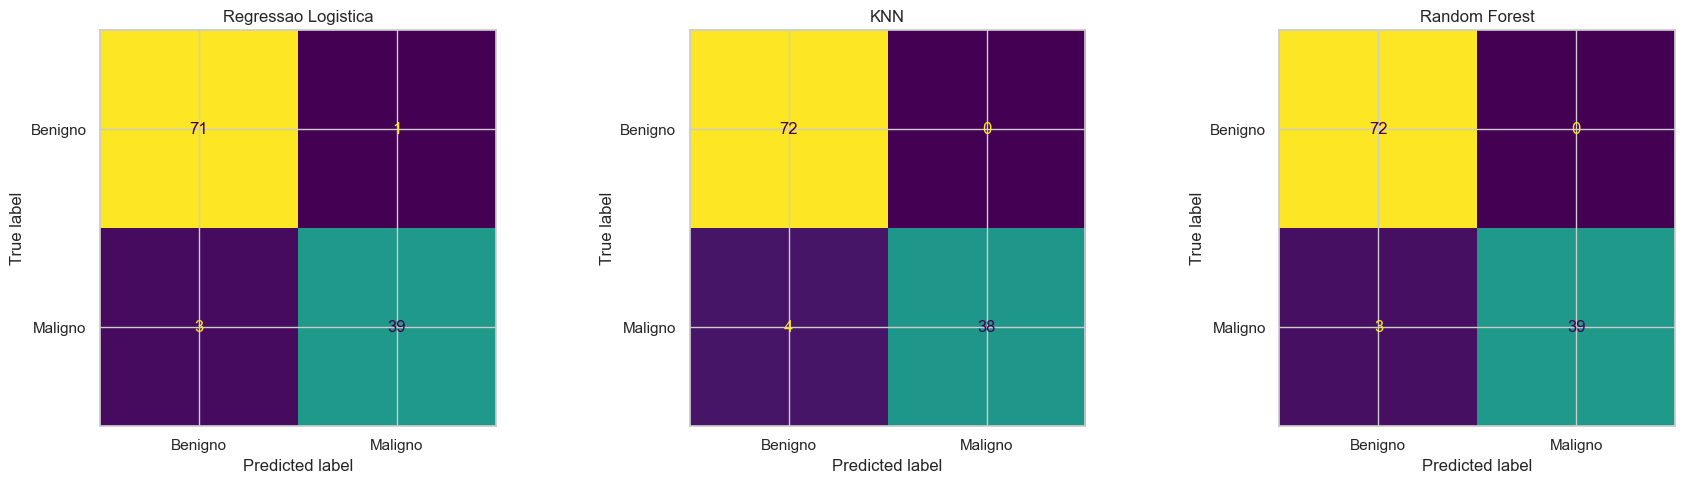

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5)) # Definições para plotagem da imagem.

for ax, (model_name, pipeline) in zip(axes, fitted_models.items()): # Cria plot para cada modelo treinado.
    y_pred = pipeline.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Benigno', 'Maligno'])
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(model_name)

plt.tight_layout()
plt.show()

As matrizes de confusão mostram que os três modelos mantiveram bom desempenho na separação entre casos benignos e malignos, com poucos erros absolutos. De modo geral, observa-se maior concentração de acertos na diagonal principal, o que indica boa capacidade de classificação. Os erros mais sensíveis para o problema são os falsos negativos, isto é, casos malignos classificados como benignos, pois representam situações de maior risco em um contexto de triagem.

### Classification Reports

In [18]:
for model_name, pipeline in fitted_models.items():
    y_pred = pipeline.predict(X_test)  # Gera as previsões do modelo no conjunto de teste.

    report_dict = classification_report(
        y_test,
        y_pred,
        target_names=['Benigno', 'Maligno'],
        output_dict=True
    )  # Converte o relatório para dicionário e facilita a montagem de uma tabela mais enxuta.

    report_df = pd.DataFrame(report_dict).T.loc[
        ['Benigno', 'Maligno'],
        ['precision', 'recall', 'f1-score']
    ]  # Mantém apenas as métricas por classe que serão discutidas na análise.

    report_df['accuracy'] = '-'  # A acurácia é global, então não se aplica individualmente a cada classe.

    accuracy_row = pd.DataFrame(
        {'precision': ['-'], 'recall': ['-'], 'f1-score': ['-'], 'accuracy': [report_dict['accuracy']]}
    , index=['Acurácia geral'])  # Acrescenta uma linha final com a proporção total de acertos do modelo.

    report_df = pd.concat([report_df, accuracy_row])  # Reúne métricas por classe e a acurácia global na mesma exibição.

    print('=' * 80)
    print(model_name)
    display(report_df)


Regressao Logistica


,precision,recall,f1-score,accuracy
Benigno,0.9595,0.9861,0.9726,-
Maligno,0.9750,0.9286,0.9512,-
Acurácia geral,-,-,-,0.9649


KNN


,precision,recall,f1-score,accuracy
Benigno,0.9474,1.0000,0.9730,-
Maligno,1.0000,0.9048,0.9500,-
Acurácia geral,-,-,-,0.9649


Random Forest


,precision,recall,f1-score,accuracy
Benigno,0.9600,1.0000,0.9796,-
Maligno,1.0000,0.9286,0.9630,-
Acurácia geral,-,-,-,0.9737


O relatório foi resumido para destacar `precision`, `recall`, `f1-score` e `accuracy`. As linhas de `Benigno` e `Maligno` mostram o comportamento do classificador em cada classe, enquanto `Acurácia geral` resume a proporção total de acertos.

Os três modelos apresentaram `accuracy` elevada, mas essa métrica sozinha não basta em um problema de triagem. O ponto mais sensível é o `recall` da classe `Maligno`, pois ele indica quantos casos de maior risco foram identificados corretamente. Nesse aspecto, Regressão Logística e Random Forest atingiram `0.9286`, enquanto o KNN ficou em `0.9048`.

A `precision` da classe `Maligno` complementa essa leitura. Random Forest e KNN alcançaram `1.0000`, sem falsos positivos nessa classe, e a Regressão Logística obteve `0.9750`. Já no `f1-score`, o Random Forest ficou em `0.9630`, a Regressão Logística em `0.9512` e o KNN em `0.9500`, mostrando resultados próximos entre si.

Em síntese, não basta buscar apenas a maior `accuracy`. O modelo mais útil neste contexto é aquele que mantém bom desempenho geral e, ao mesmo tempo, sustenta `recall` e `f1-score` elevados na classe `Maligno`. Por isso, a Regressão Logística continua sendo a opção selecionada: ela foi a mais consistente na validação cruzada e ainda oferece menor custo computacional do que o Random Forest.


## 7. Escolha do melhor modelo
A escolha do modelo final será feita com base nos resultados da validação cruzada, priorizando maior `recall`, seguido por maior `f1-score` e, por fim, maior `accuracy`. Esse critério permanece como base principal da decisão, pois está mais alinhado à comparação consistente entre modelos ao longo das partições de treino e validação.

Os Classification Reports complementam essa decisão ao mostrar como cada algoritmo se comporta no conjunto de teste, especialmente na classe `Maligno`. Essa leitura ajuda a interpretar os "trade-offs" entre `precision`, `recall` e `f1-score`, mas não substitui a validação cruzada como critério de escolha. Assim, o teste é usado como confirmação final e como apoio à interpretação prática dos resultados do modelo selecionado.

### Seleção do modelo final
Com base nos resultados da validação cruzada, o código abaixo identifica o modelo mais adequado para o problema e, em seguida, verifica como ele se comporta no conjunto de teste.

In [19]:
best_model_name = cv_results_df.iloc[0]['modelo']
best_model = fitted_models[best_model_name]  # Recupera o pipeline do modelo escolhido pela validacao cruzada.

print(f'Melhor modelo segundo a validacao cruzada: {best_model_name}')
display(cv_results_df.head(1))

print('Desempenho desse modelo no conjunto de teste:')
display(test_results_df[test_results_df['modelo'] == best_model_name].reset_index(drop=True))


Melhor modelo segundo a validacao cruzada: Regressao Logistica


,modelo,accuracy_medio,precision_medio,recall_medio,f1_medio,accuracy_std,recall_std,f1_std
0,Regressao Logistica,0.9736,0.9771,0.9529,0.9640,0.0149,0.0399,0.0207


Desempenho desse modelo no conjunto de teste:


,modelo,accuracy_teste,precision_teste,recall_teste,f1_teste
0,Regressao Logistica,0.9649,0.9750,0.9286,0.9512


## 8. Explicabilidade
Esta etapa amplia a interpretação dos resultados ao aplicar técnicas de explicabilidade aos três modelos treinados. Assim, a comparação entre algoritmos não fica restrita apenas às métricas de desempenho, mas também passa a considerar como cada modelo utiliza as variáveis do exame para sustentar suas previsões.

As técnicas foram distribuídas conforme a natureza de cada algoritmo:

- **Regressão Logística**: coeficientes padronizados e SHAP.
- **KNN**: SHAP, por ser um modelo sem coeficientes e sem feature importance nativa.
- **Random Forest**: feature importance e SHAP.


### Como interpretar os resultados
- Nos **coeficientes da Regressão Logística**, valores positivos favorecem a classe maligna e valores negativos favorecem a classe benigna.
- Na **feature importance** do Random Forest, variáveis com maior valor tendem a participar com mais força das divisões da floresta.
- No **SHAP summary plot (bar)**, as variáveis no topo apresentam maior impacto médio absoluto sobre a previsão.
- No **SHAP summary plot** tradicional, a posição horizontal mostra a intensidade do impacto e a cor indica se o valor observado está mais alto ou mais baixo.


### Regressão Logística
Na Regressão Logística, os coeficientes ajudam a interpretar a direção da influência de cada variável, enquanto o SHAP complementa essa leitura ao mostrar o impacto médio e a direção das contribuições no conjunto de teste.


,peso_absoluto
texture_worst,1.4341
radius_se,1.2333
symmetry_worst,1.0613
concave points_mean,0.9528
concavity_worst,0.9114
area_se,0.9090
compactness_se,0.9069
area_worst,0.9005
radius_worst,0.8970
concavity_mean,0.7823


C:\Users\Felipe.Sampaio\AppData\Local\Temp\ipykernel_12708\2072951869.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


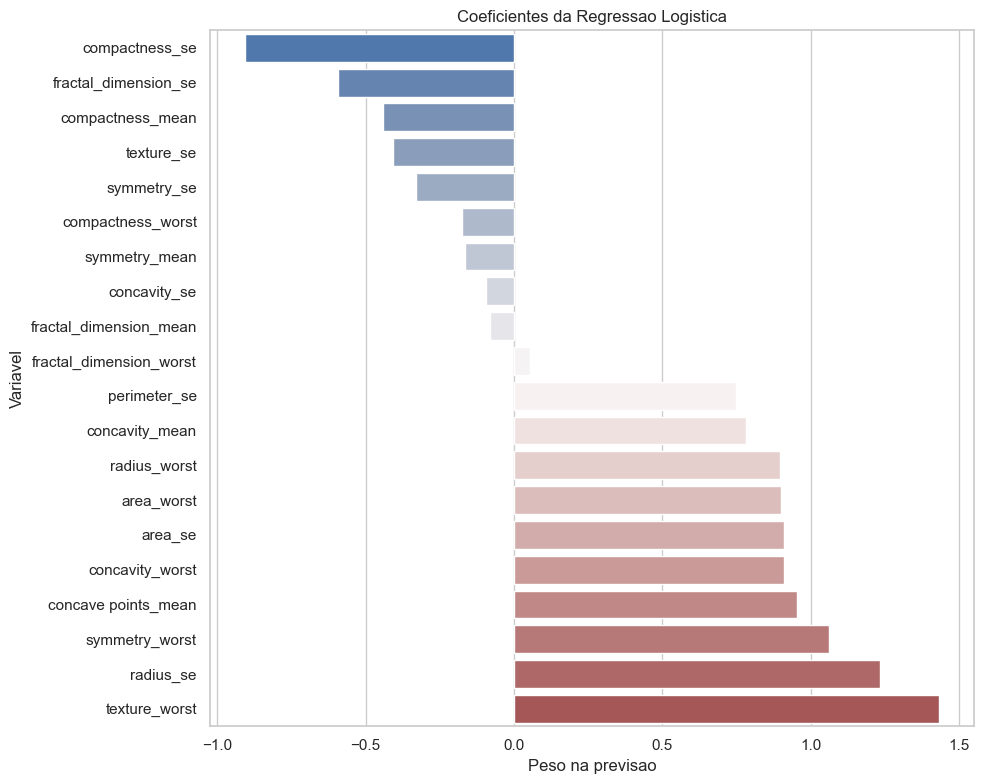

,impacto_medio_absoluto
texture_worst,1.2046
symmetry_worst,0.7303
radius_se,0.7175
concave points_mean,0.7000
compactness_se,0.6872
concavity_worst,0.6640
radius_worst,0.6450
area_worst,0.6001
concavity_mean,0.5464
concave points_worst,0.5378


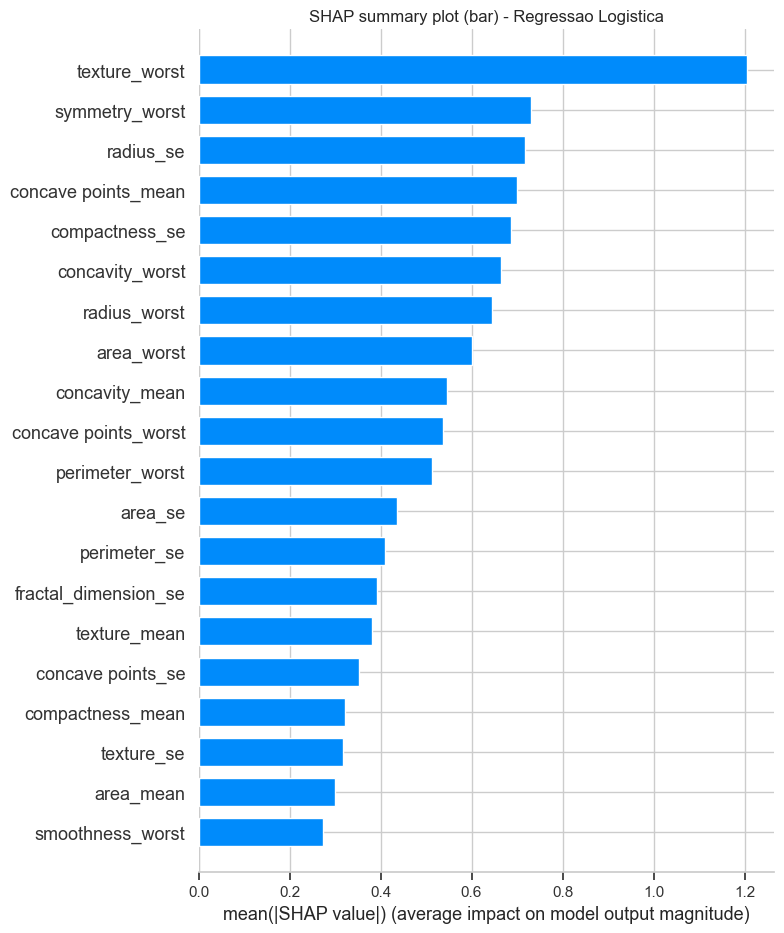

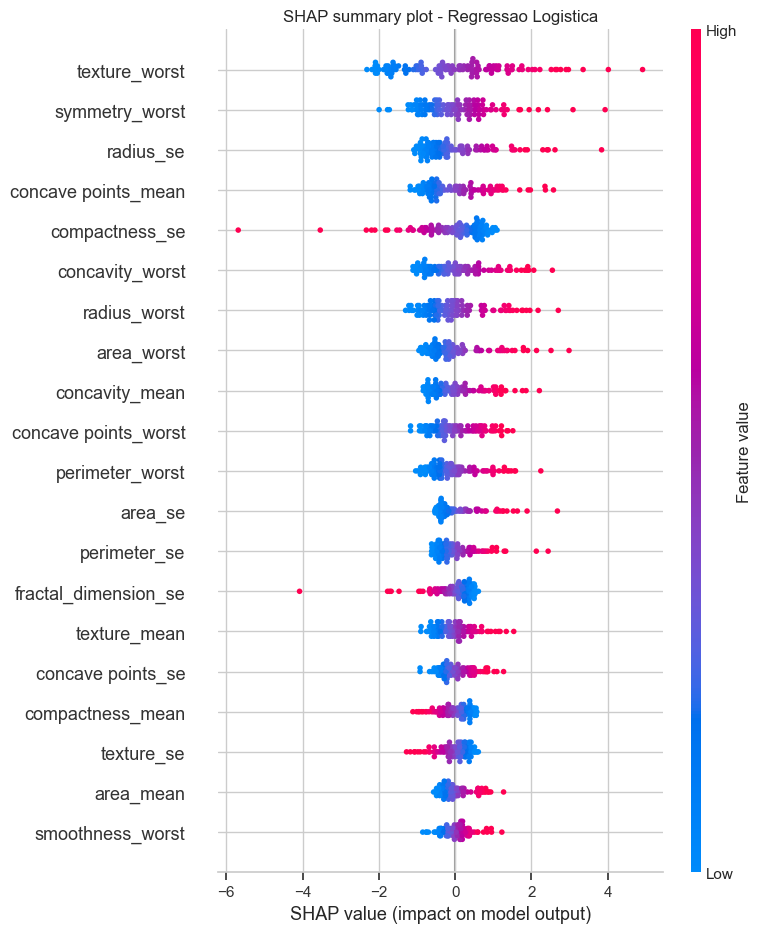

In [20]:
logistic_model = fitted_models['Regressao Logistica']

logistic_test_prepared = pd.DataFrame(
    logistic_model.named_steps['preprocessor'].transform(X_test),
    columns=numeric_features,
    index=X_test.index
)  # Recria o conjunto de teste ja preprocessado para facilitar a leitura das explicacoes.

logistic_coefficients = pd.Series(
    logistic_model.named_steps['model'].coef_[0],
    index=numeric_features
).sort_values()  # Organiza os coeficientes para observar variaveis que favorecem cada classe.

display(
    logistic_coefficients.abs().sort_values(ascending=False).head(10).to_frame('peso_absoluto')
)  # Exibe as variaveis com maior peso absoluto no modelo.

coefficients_to_plot = pd.concat([
    logistic_coefficients.head(10),
    logistic_coefficients.tail(10)
])  # Reune os pesos mais negativos e mais positivos para o grafico.

plt.figure(figsize=(10, 8))
sns.barplot(
    x=coefficients_to_plot.values,
    y=coefficients_to_plot.index,
    palette='vlag'
)
plt.title('Coeficientes da Regressao Logistica')
plt.xlabel('Peso na previsao')
plt.ylabel('Variavel')
plt.tight_layout()
plt.show()

logistic_explainer = shap.LinearExplainer(
    logistic_model.named_steps['model'],
    logistic_test_prepared
)  # Usa um explicador proprio para modelos lineares.

logistic_shap_values = logistic_explainer.shap_values(logistic_test_prepared)
logistic_shap_to_plot = logistic_shap_values[..., 1] if getattr(logistic_shap_values, 'ndim', 2) == 3 else logistic_shap_values

logistic_mean_abs_shap = pd.Series(
    np.abs(logistic_shap_to_plot).mean(axis=0),
    index=numeric_features
).sort_values(ascending=False)  # Resume o impacto medio absoluto de cada variavel no conjunto de teste.

display(logistic_mean_abs_shap.head(10).to_frame('impacto_medio_absoluto'))

shap.summary_plot(logistic_shap_to_plot, logistic_test_prepared, plot_type='bar', show=False)
plt.title('SHAP summary plot (bar) - Regressao Logistica')
plt.tight_layout()
plt.show()

shap.summary_plot(logistic_shap_to_plot, logistic_test_prepared, show=False)
plt.title('SHAP summary plot - Regressao Logistica')
plt.tight_layout()
plt.show()


Os resultados da Regressão Logística mostram maior destaque para variáveis como `texture_worst`, `symmetry_worst`, `radius_se`, `concave points_mean` e `concavity_worst`, tanto nos coeficientes em valor absoluto quanto no SHAP. Esse padrão indica que o modelo linear encontrou sinal relevante em medidas ligadas à textura, à irregularidade do contorno e à intensidade de certas regiões da lesão. Como há boa convergência entre coeficientes e SHAP, a interpretação da Regressão Logística fica mais estável: as variáveis que recebem maior peso no ajuste também aparecem como aquelas que mais alteram a previsão no conjunto de teste.


### KNN
No KNN, a decisão depende da proximidade entre observações, e por isso o modelo não fornece coeficientes ou feature importance nativos. Nesse caso, o SHAP é útil para estimar quais variáveis mais influenciam a formação dessa vizinhança no espaço de atributos padronizados. Como essa explicação foi gerada com `KernelExplainer` e amostragem reduzida, sua leitura deve ser entendida como uma aproximação interpretativa, adequada para análise exploratória, mas menos estável do que as explicações obtidas para Regressão Logística e Random Forest.


100%|██████████| 40/40 [00:01<00:00, 33.34it/s]


,impacto_medio_absoluto
concave points_mean,0.0371
radius_worst,0.0272
concavity_mean,0.0260
smoothness_worst,0.0236
perimeter_worst,0.0217
fractal_dimension_worst,0.0206
concave points_worst,0.0205
concavity_worst,0.0201
area_worst,0.0200
area_mean,0.0187


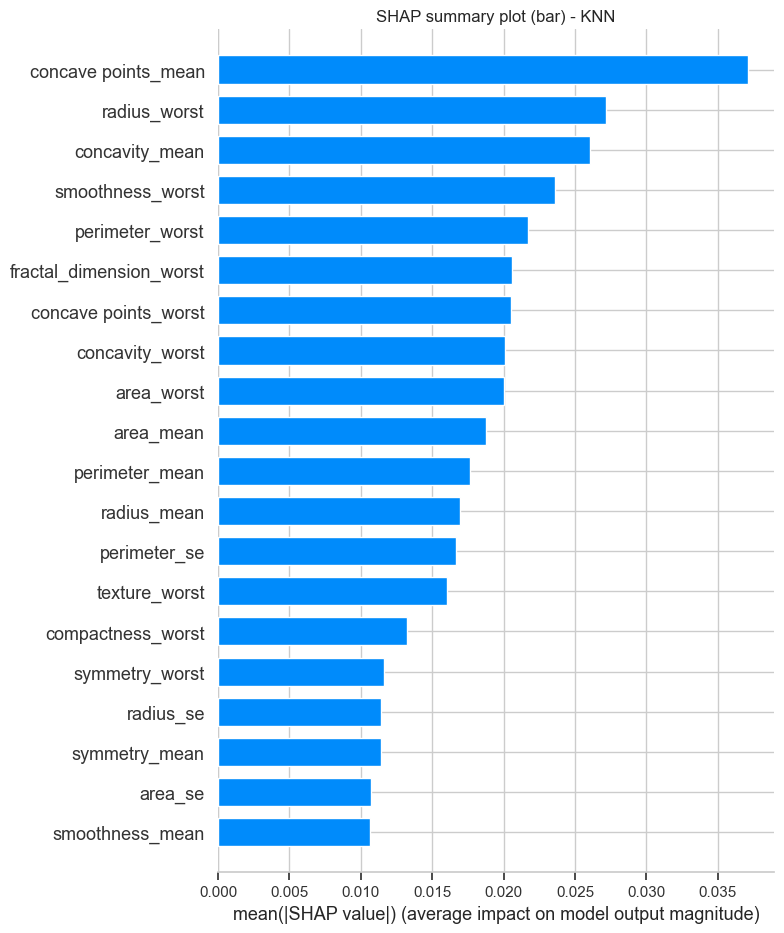

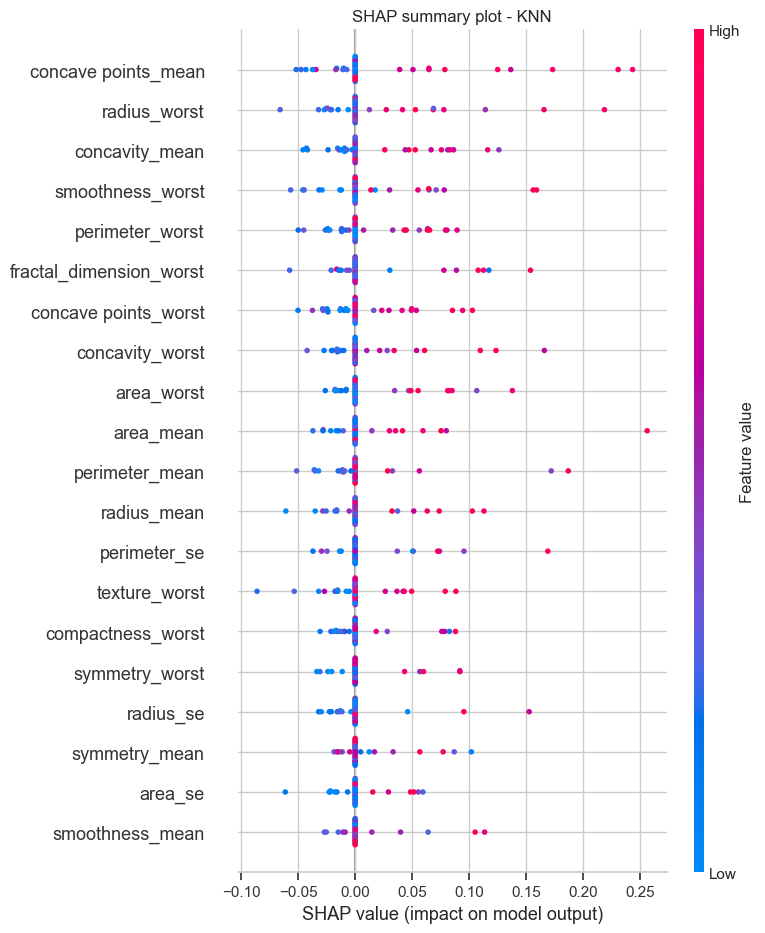

In [21]:
knn_model = fitted_models['KNN']

knn_train_prepared = pd.DataFrame(
    knn_model.named_steps['preprocessor'].transform(X_train),
    columns=numeric_features,
    index=X_train.index
)  # Prepara o conjunto de treino no mesmo espaco usado pelo modelo.

knn_test_prepared = pd.DataFrame(
    knn_model.named_steps['preprocessor'].transform(X_test),
    columns=numeric_features,
    index=X_test.index
)  # Prepara o conjunto de teste para a etapa de explicabilidade.

knn_background = shap.sample(knn_train_prepared, 40, random_state=42)  # Usa uma amostra menor de fundo para controlar o custo computacional.
knn_eval = shap.sample(knn_test_prepared, min(40, len(knn_test_prepared)), random_state=42)  # Limita a amostra explicada para manter a execucao viavel.

knn_explainer = shap.KernelExplainer(
    knn_model.named_steps['model'].predict_proba,
    knn_background
)  # Aplica um explicador generico adequado a modelos baseados em distancia.

knn_shap_values = knn_explainer.shap_values(knn_eval, nsamples=100)
knn_shap_to_plot = knn_shap_values[1] if isinstance(knn_shap_values, list) else knn_shap_values[..., 1]

knn_mean_abs_shap = pd.Series(
    np.abs(knn_shap_to_plot).mean(axis=0),
    index=numeric_features
).sort_values(ascending=False)  # Resume quais variaveis mais alteram a probabilidade prevista pelo KNN.

display(knn_mean_abs_shap.head(10).to_frame('impacto_medio_absoluto'))

shap.summary_plot(knn_shap_to_plot, knn_eval, plot_type='bar', show=False)
plt.title('SHAP summary plot (bar) - KNN')
plt.tight_layout()
plt.show()

shap.summary_plot(knn_shap_to_plot, knn_eval, show=False)
plt.title('SHAP summary plot - KNN')
plt.tight_layout()
plt.show()


No KNN, o SHAP concentrou maior impacto em variáveis associadas ao tamanho final da lesão, à textura e à irregularidade do contorno, como medidas `worst`, atributos de concavidade e pontos de concavidade. Como esse algoritmo depende da proximidade entre observações, esse resultado sugere que esses grupos de atributos são decisivos para aproximar ou afastar pacientes no espaço padronizado. Mesmo sem coeficientes próprios, a explicabilidade indica que o KNN continua se apoiando em sinais coerentes com os demais modelos, embora com uma combinação específica um pouco diferente. Ainda assim, como essa análise foi feita com amostragem reduzida para viabilizar o processamento, ela deve ser interpretada como evidência aproximada e complementar.


### Random Forest
No Random Forest, a interpretação pode ser feita por duas frentes complementares. A `feature importance` resume quanto cada variável contribui para as divisões da floresta, enquanto o SHAP detalha como essas variáveis afetam as previsões ao longo das amostras do conjunto de teste.


,importancia
area_worst,0.1529
concave points_worst,0.1345
radius_worst,0.1004
perimeter_worst,0.0876
concave points_mean,0.0837
perimeter_mean,0.0775
radius_mean,0.0594
concavity_mean,0.0516
area_mean,0.0449
concavity_worst,0.0307


C:\Users\Felipe.Sampaio\AppData\Local\Temp\ipykernel_12708\2549593065.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rf_importances.head(15).values, y=rf_importances.head(15).index, palette='Blues_r')


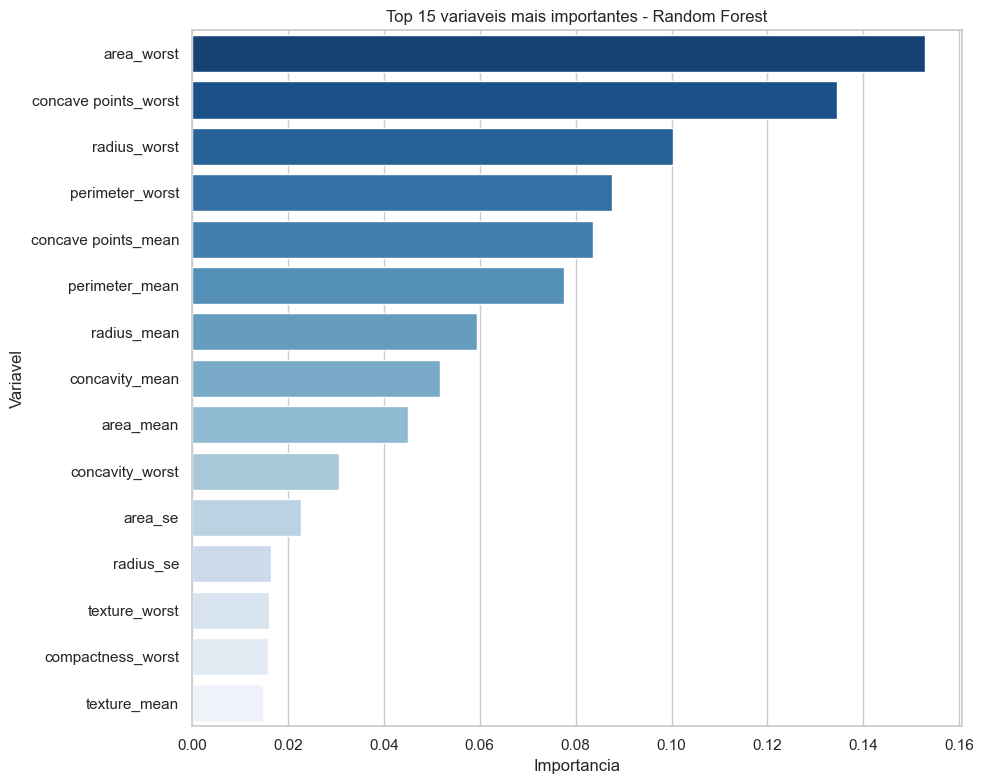

,impacto_medio_absoluto
area_worst,0.0670
concave points_worst,0.0645
radius_worst,0.0497
perimeter_worst,0.0435
concave points_mean,0.0407
perimeter_mean,0.0271
concavity_mean,0.0269
radius_mean,0.0247
area_mean,0.0212
concavity_worst,0.0205


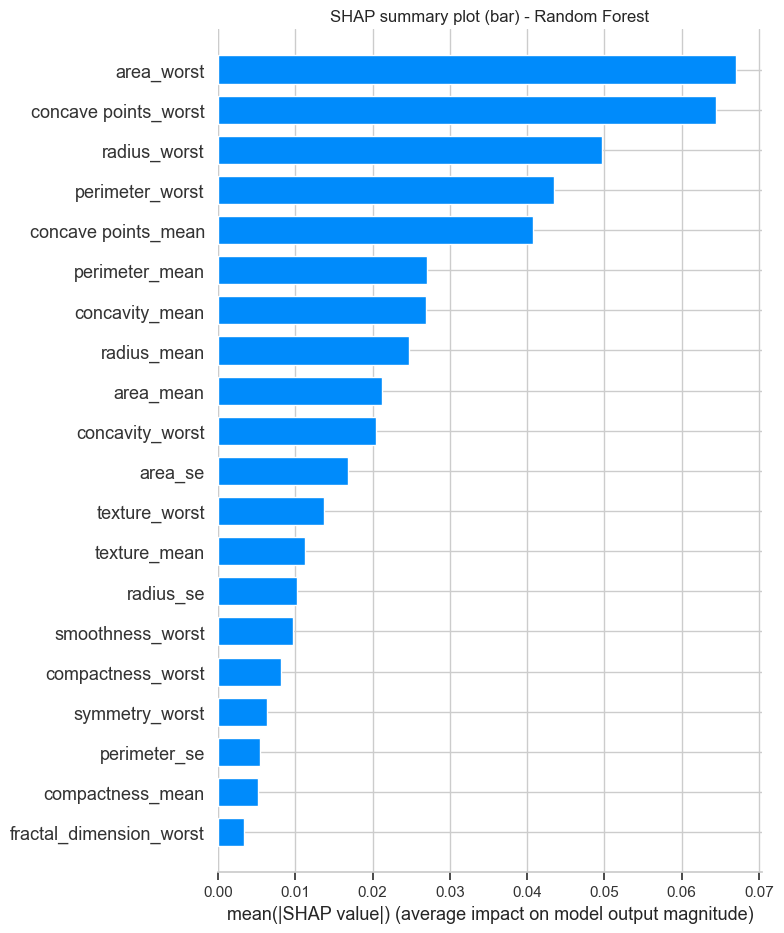

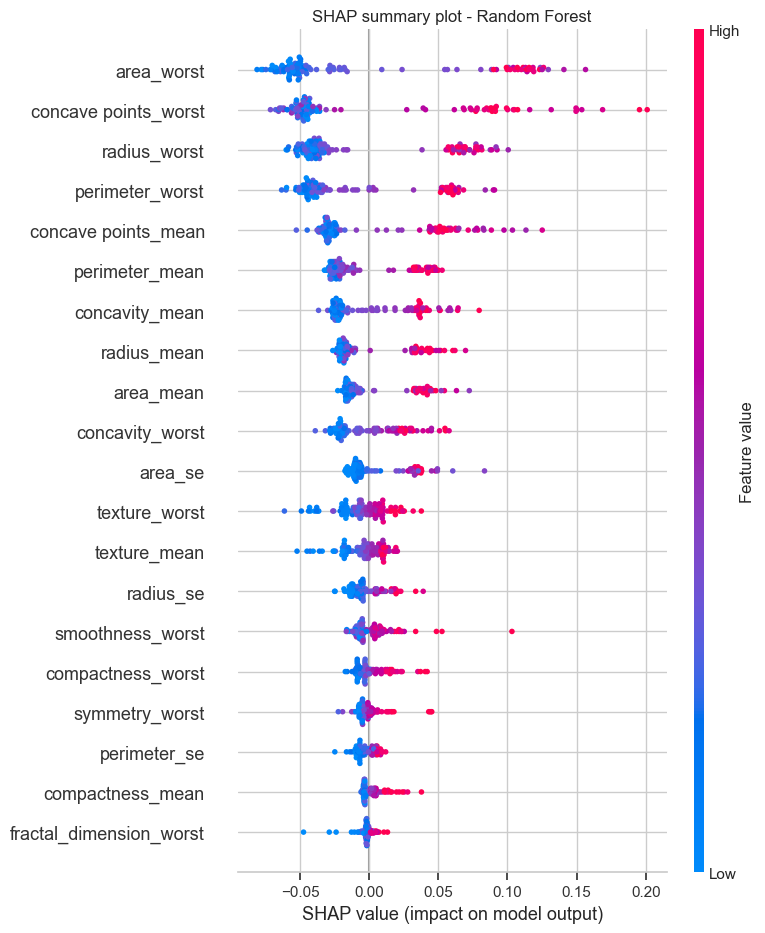

In [22]:
rf_model = fitted_models['Random Forest']

rf_test_prepared = pd.DataFrame(
    rf_model.named_steps['preprocessor'].transform(X_test),
    columns=numeric_features,
    index=X_test.index
)  # Reconstroi o conjunto de teste no formato usado pela floresta.

rf_importances = pd.Series(
    rf_model.named_steps['model'].feature_importances_,
    index=numeric_features
).sort_values(ascending=False)  # Ordena a importancia das variaveis nas decisoes da floresta.

display(rf_importances.head(10).to_frame('importancia'))

plt.figure(figsize=(10, 8))
sns.barplot(x=rf_importances.head(15).values, y=rf_importances.head(15).index, palette='Blues_r')
plt.title('Top 15 variaveis mais importantes - Random Forest')
plt.xlabel('Importancia')
plt.ylabel('Variavel')
plt.tight_layout()
plt.show()

rf_explainer = shap.TreeExplainer(
    rf_model.named_steps['model']
)  # Usa um explicador proprio para modelos baseados em arvore.

rf_shap_values = rf_explainer.shap_values(rf_test_prepared)
rf_shap_to_plot = rf_shap_values[1] if isinstance(rf_shap_values, list) else rf_shap_values[..., 1]

rf_mean_abs_shap = pd.Series(
    np.abs(rf_shap_to_plot).mean(axis=0),
    index=numeric_features
).sort_values(ascending=False)  # Resume o impacto medio absoluto das variaveis no teste.

display(rf_mean_abs_shap.head(10).to_frame('impacto_medio_absoluto'))

shap.summary_plot(rf_shap_to_plot, rf_test_prepared, plot_type='bar', show=False)
plt.title('SHAP summary plot (bar) - Random Forest')
plt.tight_layout()
plt.show()

shap.summary_plot(rf_shap_to_plot, rf_test_prepared, show=False)
plt.title('SHAP summary plot - Random Forest')
plt.tight_layout()
plt.show()


No Random Forest, houve convergência entre a `feature importance` e o SHAP, com destaque para `perimeter_worst`, `area_worst`, `concave points_worst`, `concave points_mean` e `radius_worst`. Essa repetição entre as duas técnicas fortalece a interpretação de que a floresta utiliza, de forma recorrente, medidas de tamanho e de irregularidade para separar as classes. Em comparação com os outros modelos, o Random Forest mantém foco em variáveis muito próximas, o que sugere que existe um núcleo de atributos particularmente informativos para o diagnóstico, independentemente do algoritmo utilizado.


### Síntese da explicabilidade
De forma geral, os três modelos apontam um padrão parcialmente convergente: variáveis ligadas ao tamanho final da lesão, aos pontos de concavidade e à irregularidade do contorno aparecem repetidamente entre as mais influentes. Essa repetição reforça que, mesmo com estratégias diferentes, os modelos reconhecem um núcleo semelhante de sinais relevantes para a classificação.


## 9. Conclusão 
O projeto apresentou um fluxo completo de classificação aplicado ao diagnóstico de câncer de mama, desde a exploração e o pré-processamento até a comparação entre diferentes algoritmos. A análise exploratória, a correlação e a explicabilidade mostraram um padrão consistente: variáveis ligadas ao tamanho da lesão e à irregularidade do contorno aparecem de forma recorrente entre as mais relevantes.

A Regressão Logística foi escolhida como modelo final por apresentar o melhor desempenho no critério da validação cruzada, com prioridade para `recall`, seguido por `f1-score` e `accuracy`. No conjunto de teste, ela manteve resultados altos, com `accuracy` de `0.9649`, `recall` de `0.9286` e `f1-score` de `0.9512` para a classe maligna. O Random Forest teve métricas de teste ligeiramente superiores em alguns pontos, mas a diferença foi pequena, e a Regressão Logística se mostrou mais consistente ao longo das partições, além de exigir menor custo computacional.

Na prática, a solução pode ser usada como apoio à triagem e à priorização de casos, ajudando a destacar exames com maior probabilidade de malignidade para revisão mais cuidadosa. Ainda assim, esse uso deve ser entendido como suporte à decisão, e não como substituição da avaliação clínica. Antes de qualquer aplicação real, ainda seriam necessários testes com bases externas, avaliação de viés, monitoramento contínuo de desempenho e integração com protocolos médicos. Também seria recomendável utilizar uma base de dados maior e mais diversa, para melhorar o treinamento, ampliar a capacidade de generalização do modelo e reduzir a dependência de um único conjunto de dados. A decisão final sobre o diagnóstico deve permanecer com o profissional de saúde.
